In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import cv2
import numpy as np

def extract_features(image_path, bins=8):
    img = cv2.imread(image_path) # channels in order BGR
    img = cv2.resize(img, (170, 170))
    features = {}
    
    # Color features (mean, std, median)

    for i, color in enumerate(['blue', 'green', 'red']):
        channel = img[:,:,i]
        
        features[f'{color}_mean'] = np.mean(channel)
        features[f'{color}_std'] = np.std(channel)
        features[f'{color}_median'] = np.median(channel)
        



        # Calculate histogram for each color channel , 
        hist = cv2.calcHist([channel], [0], None, [bins], [0, 256])  
         #bins is using 8 as value which is generally the default
         # None means that no mask are needed, we take all the pixels! 
         #

        # hist = hist / hist.sum()  # Normalize the histogram, so the sum is 1 
        
        # Add histogram bins to features
        for j in range(bins):
            features[f'{color}_hist_{j}'] = hist[j][0]
    
    return features

In [3]:
import matplotlib.pyplot as plt

# Generate a synthetic blue image (for testing)
test_image = np.zeros((100, 100, 3), dtype=np.uint8)
test_image[:, :, 0] = 255  # Set Blue channel to max
cv2.imwrite("test_blue.jpg", test_image)

# Extract features
features = extract_features("test_blue.jpg")
print(features["blue_mean"])  # Should print ~255.0
print(features["red_mean"])   # Should print ~0.0

254.0
0.0


In [4]:
img= cv2.imread('Non-Sperm (2).bmp') 
    

In [5]:
from pathlib import Path

p = Path("data")
# Cuenta todos los ficheros (de cualquier nivel y con cualquier extensión)
count = len(list(p.rglob("*.*")))
print(f"Total de archivos en '{p}': {count}")


Total de archivos en 'data': 3000


In [6]:
img = cv2.imread('Abnormal_Sperm (18) copy.bmp')

In [7]:
import cv2
import matplotlib.pyplot as plt

def calc_hist(sample_image, bins=8, save_path = None ):
     
    testing = cv2.imread(sample_image)
   
    if testing is None:
        print("error with the image")
        return
    
    plt.figure(figsize=(10, 5))
    
    for i, color in enumerate(['blue', 'green', 'red']):
        channel = testing[:,:,i] 
        hist = cv2.calcHist([channel], [0], None, [bins], [0, 256])  # Fixed parameters
        #hist = hist / hist.sum()  # Normalize histogram
        
        plt.plot(hist, color=color, label=color)  # Plot with color labels
    
    plt.title("Color Channel Histograms (No normalized)")
    plt.xlabel("Intensity of the channels")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches = 'tight')
        print(f'The color hist of your sample image is stored in: {save_path}')
    plt.show()
        



The color hist of your sample image is stored in: Sperm_histogram


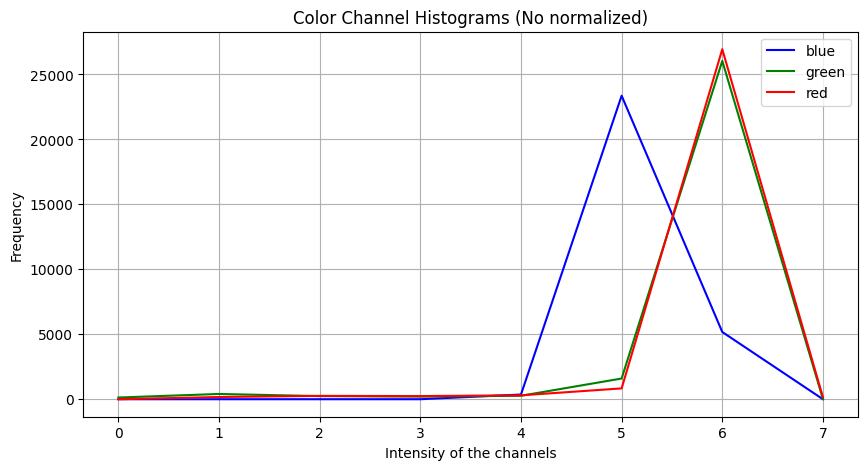

In [8]:
calc_hist('Normal_Sperm (1).bmp', save_path='Sperm_histogram')

# taking an image as sample we can see the intensity of each channel, this image look different to the ones in the presentation cuz it is bined in 8 and in the slides is in 255 to make it more easy to understand


In [9]:
# 2. Process all images
def process_dataset(root_dir):
    classes = ['Normal_Sperm', 'Abnormal_Sperm', 'Non-Sperm']
    features = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.exists(class_dir):
            continue
            
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.bmp')):
                img_path = os.path.join(class_dir, img_file)
                try:
                    feats = extract_features(img_path)
                    features.append(feats)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"Error processing {img_path}: {str(e)}")
    
    features_df = pd.DataFrame(features)
    labels_df = pd.DataFrame(labels, columns=["Labels"])
    
    return features_df, labels_df

In [10]:
# 3. Load and prepare data
# We take the process_dataset funtion and applied to the resized folder, I am not including the code that resized the dataset cuz i runned it and didnt save it 
# you can take a sample and see their dimensions is 170 x 170 

print("Processing dataset...")
X, y = process_dataset('data_resized')
print(f"Loaded {len(X)} samples with {len(X.columns)} features")


Processing dataset...
Loaded 3000 samples with 33 features


### From now till the beginning od the advanced classifiers, Ive been workin on the KNN
You will see that to avoid problems with the original Dataframe i stored it in the X_new_features variables and then i started to play with this. 

In [11]:
X_new_features = X 

In [12]:
X_new_features['blue_mean']

0       187.517889
1       180.307024
2       182.413875
3       181.428547
4       181.268651
           ...    
2995    177.873356
2996    179.594602
2997    160.258962
2998    183.384775
2999    183.819827
Name: blue_mean, Length: 3000, dtype: float64

In [13]:
X_new_features.columns

Index(['blue_mean', 'blue_std', 'blue_median', 'blue_hist_0', 'blue_hist_1',
       'blue_hist_2', 'blue_hist_3', 'blue_hist_4', 'blue_hist_5',
       'blue_hist_6', 'blue_hist_7', 'green_mean', 'green_std', 'green_median',
       'green_hist_0', 'green_hist_1', 'green_hist_2', 'green_hist_3',
       'green_hist_4', 'green_hist_5', 'green_hist_6', 'green_hist_7',
       'red_mean', 'red_std', 'red_median', 'red_hist_0', 'red_hist_1',
       'red_hist_2', 'red_hist_3', 'red_hist_4', 'red_hist_5', 'red_hist_6',
       'red_hist_7'],
      dtype='object')

### Tried to merge the stats of each channel in a global column and then dropped the used columns so it went from 33 to 36 and then after dropping to 27 

In [14]:


X_new_features['blue_global'] = (X_new_features['blue_mean'] + X_new_features['blue_median'] + X_new_features['blue_std']) / 3
X_new_features['red_global'] = (X_new_features['red_mean'] + X_new_features['red_median'] + X_new_features['red_std']) / 3
X_new_features['green_global'] = (X_new_features['green_mean'] + X_new_features['green_median'] + X_new_features['green_std']) / 3


In [15]:
X_new_features

,blue_mean,blue_std,blue_median,blue_hist_0,blue_hist_1,blue_hist_2,blue_hist_3,blue_hist_4,blue_hist_5,blue_hist_6,...,red_hist_1,red_hist_2,red_hist_3,red_hist_4,red_hist_5,red_hist_6,red_hist_7,blue_global,red_global,green_global
0,187.517889,6.646423,189.0,0.0,0.0,0.0,0.0,362.0,23363.0,5175.0,...,171.0,256.0,242.0,299.0,833.0,26942.0,157.0,127.721437,143.897861,140.878925
1,180.307024,7.374779,183.0,0.0,0.0,0.0,0.0,974.0,27697.0,229.0,...,20.0,305.0,495.0,1312.0,3768.0,22973.0,27.0,123.560601,137.793694,130.780834
2,182.413875,6.627756,183.0,0.0,0.0,0.0,41.0,464.0,27967.0,428.0,...,85.0,267.0,266.0,395.0,1214.0,26659.0,5.0,124.013877,140.929556,137.645737
3,181.428547,6.624557,183.0,0.0,0.0,0.0,0.0,660.0,27918.0,322.0,...,294.0,378.0,435.0,916.0,2093.0,24727.0,55.0,123.684368,138.191336,136.341135
4,181.268651,7.345790,183.0,0.0,0.0,0.0,0.0,877.0,27605.0,418.0,...,517.0,303.0,328.0,722.0,2870.0,24082.0,69.0,123.871480,139.102546,135.011197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,177.873356,5.332782,179.0,0.0,0.0,0.0,0.0,427.0,28454.0,19.0,...,106.0,153.0,156.0,174.0,3974.0,24280.0,57.0,120.735379,135.614424,127.041886
2996,179.594602,9.202674,181.0,0.0,0.0,0.0,68.0,1117.0,26969.0,746.0,...,160.0,328.0,509.0,1102.0,11480.0,15281.0,40.0,123.265759,133.877671,125.209233
2997,160.258962,72.078060,200.0,4657.0,914.0,533.0,229.0,1270.0,1281.0,20005.0,...,958.0,1501.0,599.0,439.0,718.0,19035.0,703.0,144.112341,153.076665,151.598901
2998,183.384775,6.061391,185.0,0.0,0.0,0.0,0.0,445.0,28308.0,147.0,...,0.0,19.0,289.0,841.0,1695.0,26056.0,0.0,124.815389,138.251316,130.172921


In [16]:
X_new_features.drop(['blue_mean', 'blue_median', 'blue_std'], axis=1, inplace=True)
X_new_features.drop(['red_mean', 'red_median', 'red_std'], axis=1, inplace=True)
X_new_features.drop(['green_mean', 'green_median', 'green_std'], axis=1, inplace=True)



In [17]:
X_new_features.columns

Index(['blue_hist_0', 'blue_hist_1', 'blue_hist_2', 'blue_hist_3',
       'blue_hist_4', 'blue_hist_5', 'blue_hist_6', 'blue_hist_7',
       'green_hist_0', 'green_hist_1', 'green_hist_2', 'green_hist_3',
       'green_hist_4', 'green_hist_5', 'green_hist_6', 'green_hist_7',
       'red_hist_0', 'red_hist_1', 'red_hist_2', 'red_hist_3', 'red_hist_4',
       'red_hist_5', 'red_hist_6', 'red_hist_7', 'blue_global', 'red_global',
       'green_global'],
      dtype='object')

In [18]:
X_new_features.shape

(3000, 27)

In [19]:
y.sample(n=9)

,Labels
2575,2
1992,1
21,0
2221,2
2490,2
932,0
2645,2
2284,2
2091,2


## This transformation of the data was used as well, i found it already in the notebook, didnt touch it 

In [20]:
def plot_distribution_before_after(X_before, X_after, feature_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Before scaling
    axes[0].hist(X_before[feature_name], bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title(f'Before Scaling: {feature_name}')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')

    # After scaling
    axes[1].hist(X_after[feature_name], bins=30, color='salmon', edgecolor='black')
    axes[1].set_title(f'After Scaling: {feature_name}')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [21]:
X.dtypes.value_counts()

float32    24
float64     3
Name: count, dtype: int64

In [22]:
# to use again the original dataframe ( 33 columns ) just replace X_new_features for X 

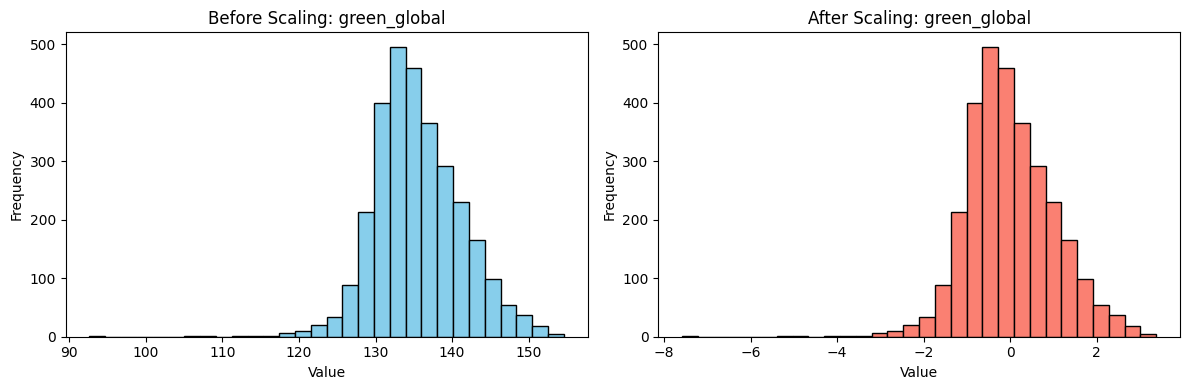

In [23]:
X_new_features.columns = X_new_features.columns.astype(str)

X_numeric = X_new_features.select_dtypes(include=['number'])

# Scale the numeric features
scaler = StandardScaler()
X_after_array = scaler.fit_transform(X_numeric)

# Convert scaled data back to DataFrame
X_after = pd.DataFrame(X_after_array, columns=X_numeric.columns)

feature_name = X_numeric.columns[26]  # or any index
plot_distribution_before_after(X_numeric, X_after, feature_name)

In [24]:
X_after.head()

,blue_hist_0,blue_hist_1,blue_hist_2,blue_hist_3,blue_hist_4,blue_hist_5,blue_hist_6,blue_hist_7,green_hist_0,green_hist_1,...,red_hist_1,red_hist_2,red_hist_3,red_hist_4,red_hist_5,red_hist_6,red_hist_7,blue_global,red_global,green_global
0,-0.146375,-0.180844,-0.239294,-0.401904,-0.737357,0.055606,0.050909,-0.141241,-0.278332,-0.086672,...,-0.406018,-0.269100,-0.554780,-0.738058,-0.825080,0.934302,-0.017595,0.437549,0.734459,0.949991
1,-0.146375,-0.180844,-0.239294,-0.401904,0.120226,0.644003,-0.627736,-0.141241,-0.433840,-0.202763,...,-1.008203,-0.030940,0.261774,0.685540,0.279071,-0.219152,-0.261131,-0.482645,-0.612475,-0.837118
2,-0.146375,-0.180844,-0.239294,-0.211200,-0.594427,0.680660,-0.600431,-0.141241,-0.250389,0.195262,...,-0.748985,-0.215636,-0.477321,-0.603146,-0.681748,0.852057,-0.302345,-0.382400,0.079479,0.377798
3,-0.146375,-0.180844,-0.239294,-0.401904,-0.319776,0.674007,-0.614976,-0.141241,-0.277117,0.609871,...,0.084504,0.323871,0.068125,0.129030,-0.351066,0.290588,-0.208677,-0.455273,-0.524731,0.146916
4,-0.146375,-0.180844,-0.239294,-0.401904,-0.015699,0.631513,-0.601803,-0.141241,-0.194504,0.434077,...,0.973824,-0.040661,-0.277216,-0.143604,-0.058758,0.103141,-0.182450,-0.413892,-0.323666,-0.088450


In [25]:
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

X_train, X_test, y_train, y_test = train_test_split(X_after, y.values.ravel(), test_size=0.2, stratify=y, random_state=42)


In [26]:
X_test

,blue_hist_0,blue_hist_1,blue_hist_2,blue_hist_3,blue_hist_4,blue_hist_5,blue_hist_6,blue_hist_7,green_hist_0,green_hist_1,...,red_hist_1,red_hist_2,red_hist_3,red_hist_4,red_hist_5,red_hist_6,red_hist_7,blue_global,red_global,green_global
2076,-0.146375,-0.180844,-0.239294,-0.401904,-0.897103,-1.329316,1.466239,-0.141241,-0.233381,-0.624005,...,-1.056059,-0.978721,0.148812,2.289020,2.371504,-2.312167,1.127027,1.402711,-0.498031,-0.760338
2997,5.783163,7.797933,4.317744,0.663245,0.535004,-2.942319,2.085746,0.217819,5.837494,3.611639,...,2.732525,5.782118,0.597433,-0.541312,-0.868344,-1.363597,1.005259,4.062494,2.759836,2.847157
1823,-0.146375,-0.180844,-0.239294,-0.392601,-0.371623,0.489233,-0.423429,-0.141241,-0.201793,-0.109890,...,0.463362,-0.186473,-0.412771,-0.791460,-0.743445,0.833458,-0.229284,0.076278,0.524013,-0.041817
690,-0.146375,-0.180844,-0.239294,-0.290272,0.497170,0.589562,-0.612917,-0.141241,0.108007,0.888488,...,-0.641309,0.051687,-0.151344,-0.277110,-0.221653,0.363242,-0.264878,-0.325335,-0.849896,-0.431216
2988,-0.146375,-0.180844,-0.239294,1.867933,0.316405,0.569605,-0.638713,-0.141241,0.408089,0.065904,...,1.548094,0.338452,-0.225577,-0.546933,0.310672,-0.207237,-0.311712,-0.439461,-0.311166,-0.456599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574,-0.146375,0.002476,3.898804,6.091316,1.482269,-0.410877,0.035953,1.817271,0.393510,1.458990,...,1.137332,2.812404,1.785148,0.751591,-0.131741,-0.625143,1.190722,0.457715,0.721643,0.497970
2359,-0.146375,-0.180844,0.059948,2.077241,0.358443,0.476200,-0.559405,-0.141241,0.824801,-0.063454,...,1.229055,1.111258,-0.264307,-0.752111,-0.885649,0.683500,-0.289232,0.231389,-0.441290,0.802737
2044,-0.146375,-0.180844,-0.239294,0.077181,1.564944,0.502945,-0.640771,-0.141241,-0.021987,-0.647223,...,0.411519,-0.973861,-0.199757,1.695972,1.023950,-1.042757,-0.311712,-0.837641,-0.599927,-0.749181
2151,-0.146375,-0.180844,-0.239294,-0.401904,-0.730351,-0.026667,0.133372,-0.141241,-0.437484,-0.809750,...,-1.087963,-1.513367,-1.151866,1.254699,4.350700,-3.261318,-0.255511,-0.117121,-1.989029,-3.458187


In [27]:
X_train.head()

,blue_hist_0,blue_hist_1,blue_hist_2,blue_hist_3,blue_hist_4,blue_hist_5,blue_hist_6,blue_hist_7,green_hist_0,green_hist_1,...,red_hist_1,red_hist_2,red_hist_3,red_hist_4,red_hist_5,red_hist_6,red_hist_7,blue_global,red_global,green_global
2945,-0.146375,-0.180844,-0.239294,-0.401904,-0.483726,-1.668995,1.769063,-0.141241,-0.116750,0.092439,...,-0.433934,0.314150,-0.157799,0.314534,-0.141146,0.164461,-0.306092,1.103068,0.312143,1.396842
92,-0.146375,-0.180844,-0.239294,-0.383298,-0.279139,0.630291,-0.575322,-0.141241,0.053337,-0.272417,...,0.654786,-0.098986,-0.506368,-0.694492,-0.860820,0.898556,-0.259258,-0.092213,0.604265,0.141447
827,-0.146375,-0.180844,-0.239294,-0.401904,-0.955957,-0.548948,0.683314,-0.141241,-0.437484,-0.614055,...,-1.064035,0.182919,-0.332084,-0.521637,-0.494399,0.671585,-0.253638,0.671683,0.650922,0.338194
2675,-0.146375,-0.180844,-0.239294,-0.401904,-0.176846,0.703875,-0.659157,-0.141241,-0.420476,-0.759997,...,-0.932432,-1.095371,-0.638695,-0.435912,-0.809656,1.000853,-0.311712,-0.790930,-1.089193,-0.856700
2995,-0.146375,-0.180844,-0.239294,-0.401904,-0.646274,0.746776,-0.656550,-0.141241,-0.381599,-0.750046,...,-0.665237,-0.769723,-0.832344,-0.913724,0.356569,0.160683,-0.204930,-1.107460,-1.093348,-1.498818


In [28]:
# 5. Base Classifier (KNN)
print("\n=== Base Classifier (KNN) ===")
knn = KNeighborsClassifier()  # it is using k = 5 by default !
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal', 'Non-Sperm']))


=== Base Classifier (KNN) ===
              precision    recall  f1-score   support

      Normal       0.53      0.66      0.59       204
    Abnormal       0.53      0.51      0.52       201
   Non-Sperm       0.92      0.72      0.81       195

    accuracy                           0.63       600
   macro avg       0.66      0.63      0.64       600
weighted avg       0.66      0.63      0.64       600



In [29]:
from sklearn.feature_selection import SequentialFeatureSelector

###  n_features_to_select perfom well with 29, gives acuraccy of  0.66 % and the precision of each class is increased 

=== Base Classifier (KNN)  without feature selection ===
              precision    recall  f1-score   support

      Normal       0.55      0.69      0.61       204
    Abnormal       0.52      0.45      0.48       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.62       600
   macro avg       0.64      0.62      0.63       600
weighted avg       0.64      0.62      0.62       600


=== Base Classifier (KNN) - using 29  features and having sequential forward=== this part is extracted from the code bellow !! 
Please check the notes.




              precision    recall  f1-score   support

      Normal       0.60      0.69      0.64       204
    Abnormal       0.57      0.55      0.56       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.66       600
   macro avg       0.67      0.66      0.66       600
weighted avg       0.67      0.66      0.66       600

 

 NOTE: 
 
 THE CODE BELLOW IS USING n_import_feat_knn = 19  and use the   dataframe which had 27 features
AGAIN, Currently it is using the dataframe that has 27 features  it is just for experimntation. 


If you want to see the output that has accuracu 0.66 u must use the original dataframe (33 features) and set n_import_feat_knn = 29 
 

In [30]:

my_direction = 'forward'
n_import_feat_knn = 19 

sfs = SequentialFeatureSelector(knn, n_features_to_select=n_import_feat_knn, direction=my_direction, scoring='accuracy', cv=5, n_jobs=-1) #accuracy as scoring since we have a balanced dataset
sfs.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,n_features_to_select,19
,tol,None
,direction,'forward'
,scoring,'accuracy'
,cv,5
,n_jobs,-1
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [31]:
selected_features = sfs.get_support()
selected_features



array([ True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
       False,  True,  True,  True, False,  True, False, False, False])

In [32]:
selected_feature_names = X_train.columns[selected_features]

print("Features seleccionadas:", list(selected_feature_names))

Features seleccionadas: ['blue_hist_0', 'blue_hist_1', 'blue_hist_2', 'blue_hist_3', 'blue_hist_5', 'blue_hist_6', 'blue_hist_7', 'green_hist_0', 'green_hist_1', 'green_hist_2', 'green_hist_3', 'green_hist_4', 'green_hist_7', 'red_hist_0', 'red_hist_1', 'red_hist_3', 'red_hist_4', 'red_hist_5', 'red_hist_7']


In [33]:
print(f"\n=== Base Classifier (KNN) - using {n_import_feat_knn}  features and having sequential {my_direction}===")
knn = KNeighborsClassifier()  # it is using k = 5 by default 
knn.fit(X_train[selected_feature_names], y_train)
y_pred = knn.predict(X_test[selected_feature_names])
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal', 'Non-Sperm']))


=== Base Classifier (KNN) - using 19  features and having sequential forward===
              precision    recall  f1-score   support

      Normal       0.54      0.63      0.58       204
    Abnormal       0.54      0.55      0.55       201
   Non-Sperm       0.89      0.74      0.81       195

    accuracy                           0.64       600
   macro avg       0.66      0.64      0.65       600
weighted avg       0.66      0.64      0.64       600



## In Conclusion i got those results 

-- When we use the 33 features, no feature engineering, not best feature selection ( the one we have been using by now we got this following report):

=== Base Classifier (KNN)  without feature selection ===
              precision    recall  f1-score   support

      Normal       0.55      0.69      0.61       204
    Abnormal       0.52      0.45      0.48       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.62       600
   macro avg       0.64      0.62      0.63       600
weighted avg       0.64      0.62      0.62       600





When we apply feature selection , sequential forward.... n_features = 29 we got this report: 




              precision    recall  f1-score   support

      Normal       0.60      0.69      0.64       204
    Abnormal       0.57      0.55      0.56       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.66       600
   macro avg       0.67      0.66      0.66       600
weighted avg       0.67      0.66      0.66       600





when we apply feature engineering (27 features) + sequential forward n_feature = 19 
we got this report



 === Base Classifier (KNN) - using 19  features and having sequential forward===
              precision    recall  f1-score   support

      Normal       0.59      0.68      0.63       204
    Abnormal       0.58      0.57      0.57       201
   Non-Sperm       0.87      0.74      0.80       195

    accuracy                           0.66       600
   macro avg       0.68      0.66      0.67       600
weighted avg       0.68      0.66      0.67       600

In [34]:
# 6. Advanced Classifiers with Hyperparameter Tuning

## Random Forest
print("\n=== Random Forest (Optimized) ===")
rf_params = {
    'n_estimators': [100, 150, 250, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Best params: {rf.best_params_}")
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))



=== Random Forest (Optimized) ===
Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.66      0.67      0.66       204
           1       0.62      0.65      0.64       201
           2       0.87      0.83      0.85       195

    accuracy                           0.71       600
   macro avg       0.72      0.71      0.71       600
weighted avg       0.72      0.71      0.71       600



Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.65      0.61      0.63       204
           1       0.59      0.65      0.62       201
           2       0.83      0.81      0.82       195

    accuracy                           0.69       600
   macro avg       0.69      0.69      0.69       600
weighted avg       0.69      0.69      0.69       600



In [35]:
rf.best_score_

np.float64(0.6879166666666666)

In [36]:
report = pd.DataFrame(rf.cv_results_)
report[['param_n_estimators','mean_test_score']]

,param_n_estimators,mean_test_score
0,100,0.678333
1,150,0.683750
2,250,0.682500
3,300,0.686250
4,100,0.682500
5,150,0.685417
6,250,0.685833
7,300,0.687083
8,100,0.676250
9,150,0.674167


In [37]:
# ## SVM
# print("\n=== SVM (Optimized) ===")
# svm_params = {
#     'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],  # Test the C with exponential steps , we will choose the proper C below
#     'gamma': ['scale', 'auto'],
#     'kernel': ['rbf', 'linear' ]
# }
# svm = GridSearchCV(SVC(), svm_params, cv=3, n_jobs=-1)
# svm.fit(X_train, y_train)
# print(f"Best params: {svm.best_params_}")
# y_pred_svm = svm.predict(X_test)                                        
# print(classification_report(y_test, y_pred_svm))

In [38]:
# 7. Visualization
def plot_results(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Abnormal', 'Non-Sperm'],
                yticklabels=['Normal', 'Abnormal', 'Non-Sperm'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


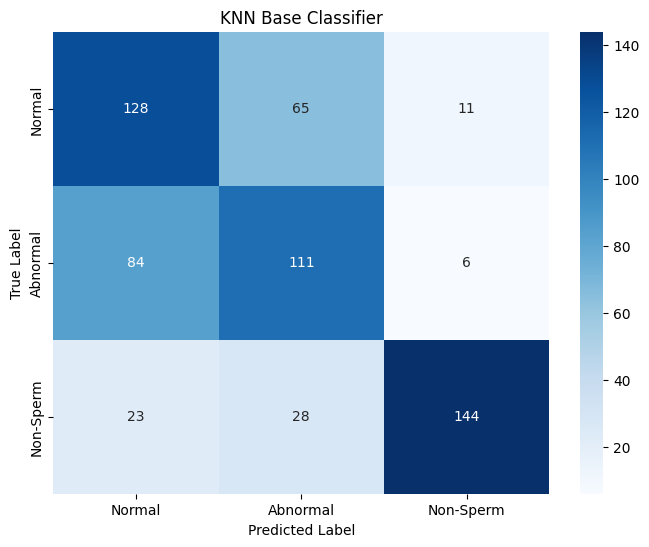

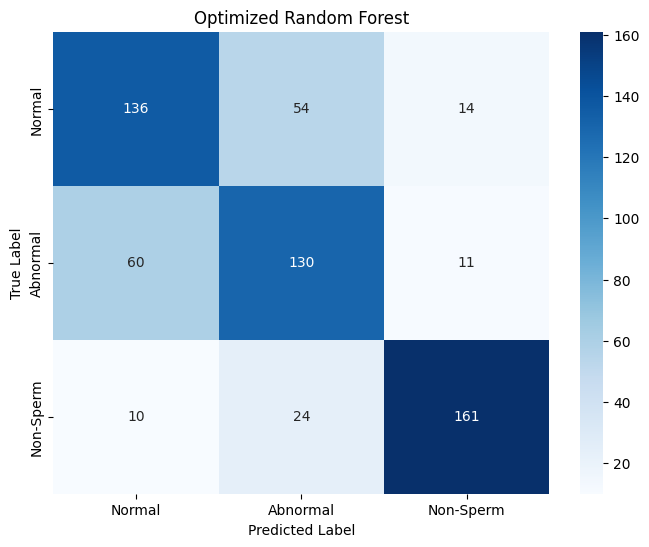

NameError: name 'y_pred_svm' is not defined

In [39]:
plot_results(y_test, y_pred, "KNN Base Classifier")
plot_results(y_test, y_pred_rf, "Optimized Random Forest")
plot_results(y_test, y_pred_svm, "Optimized SVM")

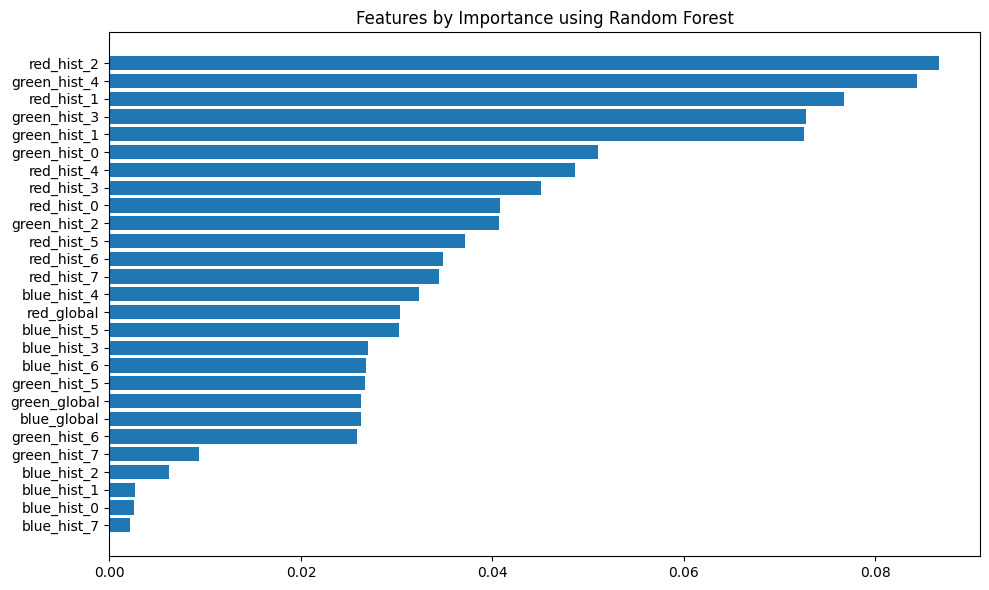

In [43]:
# 8. Feature Importance Analysis
plt.figure(figsize=(10, 6))
importances = rf.best_estimator_.feature_importances_
sorted_idx = np.argsort(importances)  # Top 10 features
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title("Features by Importance using Random Forest")
plt.tight_layout()
plt.show()

# Feature Reduction - Random Forest

### With 25 max features

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score

# Grid search
rf_params = {
    'n_estimators': [100, 150, 250, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, n_jobs=-1)
rf.fit(X_train, y_train)

# Use best estimator (which has feature_importances_)
best_rf = rf.best_estimator_

# Feature selection
selector = SelectFromModel(
    best_rf,
    threshold="mean",
    max_features=25
)
selector.fit(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected features:")
print(selected_features)

# Reduce datasets
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)

print("\nShape before reduction:", X_train.shape)
print("Shape after reduction:", X_train_reduced.shape)

# Train final model on reduced features
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_reduced, y_train)

# Evaluate
y_pred = final_model.predict(X_test_reduced)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Selected features:
Index(['green_hist_0', 'green_hist_1', 'green_hist_2', 'green_hist_3',
       'green_hist_4', 'red_hist_0', 'red_hist_1', 'red_hist_2', 'red_hist_3',
       'red_hist_4'],
      dtype='object')

Shape before reduction: (2400, 27)
Shape after reduction: (2400, 10)

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63       204
           1       0.59      0.58      0.59       201
           2       0.84      0.82      0.83       195

    accuracy                           0.68       600
   macro avg       0.68      0.68      0.68       600
weighted avg       0.68      0.68      0.68       600


Accuracy: 0.6800
Precision: 0.6821

Confusion Matrix:
[[132  57  15]
 [ 69 117  15]
 [ 13  23 159]]


## with 5 max features

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score

# Grid search
rf_params = {
    'n_estimators': [100, 150, 250, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, n_jobs=-1)
rf.fit(X_train, y_train)

# Use best estimator (which has feature_importances_)
best_rf = rf.best_estimator_

# Feature selection
selector = SelectFromModel(
    best_rf,
    threshold="mean",
    max_features=5
)
selector.fit(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected features:")
print(selected_features)

# Reduce datasets
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)

print("\nShape before reduction:", X_train.shape)
print("Shape after reduction:", X_train_reduced.shape)

# Train final model on reduced features
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_reduced, y_train)

# Evaluate
y_pred = final_model.predict(X_test_reduced)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Selected features:
Index(['green_hist_1', 'green_hist_3', 'green_hist_4', 'red_hist_1',
       'red_hist_2'],
      dtype='object')

Shape before reduction: (2400, 27)
Shape after reduction: (2400, 5)

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.55      0.56       204
           1       0.55      0.58      0.57       201
           2       0.81      0.79      0.80       195

    accuracy                           0.64       600
   macro avg       0.64      0.64      0.64       600
weighted avg       0.64      0.64      0.64       600


Accuracy: 0.6400
Precision: 0.6418

Confusion Matrix:
[[113  69  22]
 [ 69 117  15]
 [ 16  25 154]]


## with 1 max features

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score

# Grid search
rf_params = {
    'n_estimators': [100, 150, 250, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, n_jobs=-1)
rf.fit(X_train, y_train)

# Use best estimator (which has feature_importances_)
best_rf = rf.best_estimator_

# Feature selection
selector = SelectFromModel(
    best_rf,
    threshold="mean",
    max_features=1
)
selector.fit(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print("Selected features:")
print(selected_features)

# Reduce datasets
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)

print("\nShape before reduction:", X_train.shape)
print("Shape after reduction:", X_train_reduced.shape)

# Train final model on reduced features
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train_reduced, y_train)

# Evaluate
y_pred = final_model.predict(X_test_reduced)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Selected features:
Index(['red_hist_2'], dtype='object')

Shape before reduction: (2400, 27)
Shape after reduction: (2400, 1)

Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.43      0.41       204
           1       0.41      0.43      0.42       201
           2       0.63      0.54      0.59       195

    accuracy                           0.47       600
   macro avg       0.48      0.47      0.47       600
weighted avg       0.48      0.47      0.47       600


Accuracy: 0.4650
Precision: 0.4760

Confusion Matrix:
[[ 87  82  35]
 [ 89  86  26]
 [ 45  44 106]]


# Feature Reduction  - XGBOOST

## With all Features

In [45]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score


final_model = xgb.XGBClassifier(n_estimators=100, random_state=42)


final_model.fit(X_train,y_train)
y_pred = final_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.61      0.61       204
           1       0.61      0.64      0.62       201
           2       0.86      0.84      0.85       195

    accuracy                           0.69       600
   macro avg       0.70      0.70      0.70       600
weighted avg       0.70      0.69      0.69       600

Accuracy: 0.6933
Precision: 0.6955
[[124  67  13]
 [ 60 128  13]
 [ 16  15 164]]


## With max 25 Features

In [46]:
import xgboost as xgb
from sklearn.feature_selection import SelectFromModel

xgb = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train,y_train)


selector = SelectFromModel(
    xgb,
    threshold="mean",
    max_features=25
)
X_train_reduced = selector.fit_transform(X_train,y_train)
X_test_reduced = selector.transform(X_test)

print(X_train.shape)
print(X_train_reduced.shape)

final_model.fit(X_train_reduced,y_train)
y_pred = final_model.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(confusion_matrix(y_test, y_pred))

(2400, 27)
(2400, 8)
              precision    recall  f1-score   support

           0       0.61      0.61      0.61       204
           1       0.57      0.61      0.59       201
           2       0.86      0.80      0.83       195

    accuracy                           0.67       600
   macro avg       0.68      0.67      0.68       600
weighted avg       0.68      0.67      0.67       600

Accuracy: 0.6717
Precision: 0.6780
[[124  69  11]
 [ 63 123  15]
 [ 15  24 156]]


## With max 5 features

In [47]:
import xgboost as xgb
from sklearn.feature_selection import SelectFromModel

xgb = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train,y_train)


selector = SelectFromModel(
    xgb,
    threshold="mean",
    max_features=5
)
X_train_reduced = selector.fit_transform(X_train,y_train)
X_test_reduced = selector.transform(X_test)

print(X_train.shape)
print(X_train_reduced.shape)

final_model.fit(X_train_reduced,y_train)
y_pred = final_model.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(confusion_matrix(y_test, y_pred))

(2400, 27)
(2400, 5)
              precision    recall  f1-score   support

           0       0.58      0.61      0.60       204
           1       0.57      0.56      0.56       201
           2       0.79      0.76      0.78       195

    accuracy                           0.64       600
   macro avg       0.65      0.64      0.65       600
weighted avg       0.65      0.64      0.64       600

Accuracy: 0.6433
Precision: 0.6453
[[124  57  23]
 [ 71 113  17]
 [ 17  29 149]]


## With max 1 features

In [48]:
import xgboost as xgb
from sklearn.feature_selection import SelectFromModel

xgb = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train,y_train)


selector = SelectFromModel(
    xgb,
    threshold="mean",
    max_features=1
)
X_train_reduced = selector.fit_transform(X_train,y_train)
X_test_reduced = selector.transform(X_test)

print(X_train.shape)
print(X_train_reduced.shape)

final_model.fit(X_train_reduced,y_train)
y_pred = final_model.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(confusion_matrix(y_test, y_pred))

(2400, 27)
(2400, 1)
              precision    recall  f1-score   support

           0       0.42      0.42      0.42       204
           1       0.47      0.51      0.49       201
           2       0.71      0.66      0.69       195

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.53       600
weighted avg       0.53      0.53      0.53       600

Accuracy: 0.5267
Precision: 0.5322
[[ 85  84  35]
 [ 82 102  17]
 [ 35  31 129]]
